# GPU Accelerated Version

This is the same thing as the other notebook, but using GPU accelerated estimators


## Setup
imports, data download, train/test split

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
# from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_predict, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

In [27]:
from cuml.neighbors import KNeighborsClassifier 

In [28]:
mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target

In [29]:
def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap='binary')
    plt.axis('off')

In [30]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

## Building a better classifier

In [31]:
knn_clf = KNeighborsClassifier()
knn_preds = cross_val_predict(knn_clf, X_train, y_train, cv=3, n_jobs=-1)

In [32]:
print(type(knn_clf))

<class 'cuml.neighbors.kneighbors_classifier.KNeighborsClassifier'>


In [33]:
print(classification_report(y_train, knn_preds))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      5923
           1       0.95      0.99      0.97      6742
           2       0.98      0.96      0.97      5958
           3       0.96      0.96      0.96      6131
           4       0.98      0.96      0.97      5842
           5       0.96      0.96      0.96      5421
           6       0.98      0.99      0.98      5918
           7       0.96      0.97      0.97      6265
           8       0.98      0.92      0.95      5851
           9       0.95      0.96      0.95      5949

    accuracy                           0.97     60000
   macro avg       0.97      0.97      0.97     60000
weighted avg       0.97      0.97      0.97     60000



In [34]:
print(accuracy_score(y_train, knn_preds))

0.9674166666666667


default works pretty well tbh, let's just tune the hyperparameters a bit

get our grid of parameters, and do a grid search for the best params.

we can fit on a subset of the data, and then refit on the entire set of data with the best set of params

this means we get the biggest improvement, and then make tiny microadjustments based on the entire set

In [35]:
knn_clf = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [3, 4, 5, 6, 7],
    'weights': ['uniform', 'distance']
}

grid_search = GridSearchCV(knn_clf, param_grid, cv=3, verbose=2) 

grid_search.fit(X_train, y_train) # fit on a subset of the data to make it faster
grid_search.best_params_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END .....................n_neighbors=3, weights=uniform; total time=   0.4s
[CV] END .....................n_neighbors=3, weights=uniform; total time=   0.4s
[CV] END .....................n_neighbors=3, weights=uniform; total time=   0.4s
[CV] END ....................n_neighbors=3, weights=distance; total time=   0.4s
[CV] END ....................n_neighbors=3, weights=distance; total time=   0.4s
[CV] END ....................n_neighbors=3, weights=distance; total time=   0.4s
[CV] END .....................n_neighbors=4, weights=uniform; total time=   0.4s
[CV] END .....................n_neighbors=4, weights=uniform; total time=   0.4s
[CV] END .....................n_neighbors=4, weights=uniform; total time=   0.4s
[CV] END ....................n_neighbors=4, weights=distance; total time=   0.4s
[CV] END ....................n_neighbors=4, weights=distance; total time=   0.4s
[CV] END ....................n_neighbors=4, weig

{'n_neighbors': 4, 'weights': 'distance'}

In [36]:
print(grid_search.best_score_) # cv score of the best combination
model = grid_search.best_estimator_
# print(grid_search.cv_results_)

0.9703500000000002


In [37]:
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=4, weights='distance')

In [38]:
test_preds = model.predict(X_test)
print(classification_report(y_test, test_preds))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.97      1.00      0.98      1135
           2       0.98      0.96      0.97      1032
           3       0.97      0.96      0.97      1010
           4       0.98      0.97      0.97       982
           5       0.96      0.97      0.96       892
           6       0.98      0.99      0.98       958
           7       0.96      0.97      0.96      1028
           8       0.99      0.94      0.97       974
           9       0.96      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [39]:
print(accuracy_score(y_test, test_preds))

0.9714


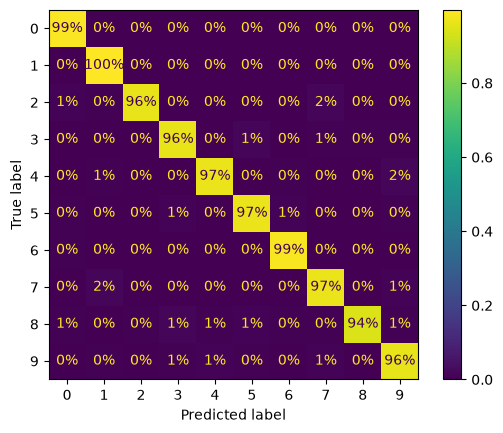

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, test_preds, normalize='true', values_format='.0%')

wow this is pretty insanely good, doesnt really have a blatant error or anything. 

## Shifting the image

let's write a function that shifts an image  

In [41]:
from scipy.ndimage import shift

# need to write a function that shifts an image

# this function takes in an image and how much to shift it by, reshapes and shifts the image 
#   and puts it back how it originally was (-1 flattens it into a 1d array)
def shift_image(image, x, y):
    return shift(image.reshape(28,28), [x,y], cval=0).reshape(-1) # cval = 0 means to fill the empty part of the image with 0 

now that we have our function, we need to go through the training set, and create a new shifted each image up/down/left/right. we can then add all these to the training set.

In [42]:
# add everything to a normal python list first, it's faster since np.append() copies over the entire thing
shifted_images = []
shifted_images_labels = []

for i in range(np.shape(X_train)[0]):
    image = X_train[i]
    shifted_images.append(shift_image(image, 1, 0))
    shifted_images.append(shift_image(image, -1, 0))
    shifted_images.append(shift_image(image, 0, 1))
    shifted_images.append(shift_image(image, 0,-1))
    for j in range(4):
        shifted_images_labels.append(y_train[i])

In [43]:
shifted_images = np.array(shifted_images)
shifted_images_labels = np.array(shifted_images_labels)

In [44]:
print(shifted_images.shape)
print(X_train.shape)

(240000, 784)
(60000, 784)


In [45]:
X_train_with_shifted = np.append(X_train, shifted_images, axis=0) # axis=0 means that rows (the actual images) will be added below the orignal rows
y_train_with_shifted = np.append(y_train, shifted_images_labels, axis=0)

In [46]:
print(X_train_with_shifted.shape)
print(y_train_with_shifted.shape)

(300000, 784)
(300000,)


In [47]:
grid_search.fit(X_train_with_shifted, y_train_with_shifted)
model = grid_search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END .....................n_neighbors=3, weights=uniform; total time=   8.1s
[CV] END .....................n_neighbors=3, weights=uniform; total time=   7.9s
[CV] END .....................n_neighbors=3, weights=uniform; total time=   7.9s
[CV] END ....................n_neighbors=3, weights=distance; total time=   7.9s
[CV] END ....................n_neighbors=3, weights=distance; total time=   7.9s
[CV] END ....................n_neighbors=3, weights=distance; total time=   7.9s
[CV] END .....................n_neighbors=4, weights=uniform; total time=   8.0s
[CV] END .....................n_neighbors=4, weights=uniform; total time=   8.0s
[CV] END .....................n_neighbors=4, weights=uniform; total time=   8.0s
[CV] END ....................n_neighbors=4, weights=distance; total time=   8.0s
[CV] END ....................n_neighbors=4, weights=distance; total time=   8.0s
[CV] END ....................n_neighbors=4, weig

In [56]:
print(grid_search.best_params_)

{'n_neighbors': 4, 'weights': 'distance'}


In [52]:
test_preds = model.predict(X_test)
print(classification_report(y_test, test_preds))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.97      1.00      0.98      1135
           2       0.99      0.97      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.97      0.98       982
           5       0.97      0.97      0.97       892
           6       0.98      0.99      0.99       958
           7       0.97      0.97      0.97      1028
           8       0.99      0.95      0.97       974
           9       0.96      0.97      0.96      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [53]:
print(accuracy_score(y_test, test_preds))

0.9763


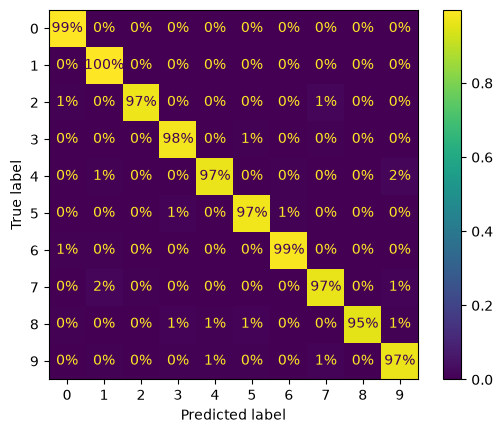

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, test_preds, normalize='true', values_format='.0%')

not bad, that's an improvement


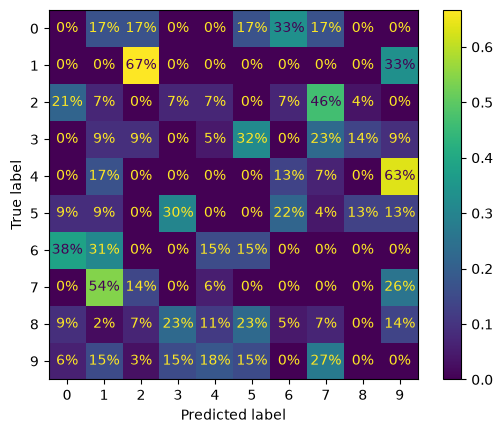

In [55]:
sample_weight = (test_preds != y_test)
ConfusionMatrixDisplay.from_predictions(y_test , test_preds,
                                        sample_weight=sample_weight,
                                        normalize="true", values_format=".0%")
plt.show()

a handful of larger error categories, but nothing insanely huge